# 02 — Portland contributions fundraising profiles (2024)

This notebook builds the **primary 2024 private-fundraising profiles** from the
cleaned Portland contributions source.

The cleaned source remains multi-year. The analytical year is filtered here.

We preserve the earlier profile logic:

- dollars by contribution-size bin;
- dollar share by bin;
- contribution-record count by bin;
- contribution-record share by bin;
- total, mean, median, minimum, and maximum contribution.

Public matching payments are excluded from private fundraising.

**Terminology:** `contribution_count` counts contribution records, not unique donors.


## 1. Setup

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 190)

cwd = Path.cwd().resolve()

if (cwd / "pyproject.toml").exists():
    ROOT = cwd
elif (cwd.parent / "pyproject.toml").exists():
    ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Could not find repository root. "
        "Expected pyproject.toml in the current directory or its parent."
    )

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from helpers.paths import (
    CLEAN,
    PROCESSED,
    fundraising_processed_dir,
    orestar_file_audit_path,
    orestar_transactions_path,
    spending_processed_dir,
)

print("ROOT:", ROOT)

YEAR = 2024
CONTEST = "city_council"

CONTRIBUTIONS_PATH = (
    CLEAN
    / "portland_contributions"
    / "contributions.csv"
)

CROSSWALK_PATH = (
    PROCESSED
    / "master"
    / f"candidate_source_crosswalk_{YEAR}.csv"
)

OUTPUT_DIR = fundraising_processed_dir(
    YEAR,
    CONTEST,
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("Contributions:", CONTRIBUTIONS_PATH)
print("Crosswalk:", CROSSWALK_PATH)
print("Output:", OUTPUT_DIR)


ROOT: /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis
Contributions: /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis/data/clean/portland_contributions/contributions.csv
Crosswalk: /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis/data/processed/master/candidate_source_crosswalk_2024.csv
Output: /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis/data/processed/fundraising/2024/city_council


## 2. Load the complete cleaned contribution source

We intentionally inspect all available years before filtering to 2024.


In [2]:
contributions = pd.read_csv(
    CONTRIBUTIONS_PATH,
    low_memory=False,
)

print("Rows:", f"{len(contributions):,}")
print("Columns:", len(contributions.columns))

print("\nRecords by year:")
display(
    contributions["year"]
    .value_counts(dropna=False)
    .sort_index()
)


Rows: 53,596
Columns: 24

Records by year:


year
2024    43211
2026    10385
Name: count, dtype: int64

## 3. Define the 2024 private-fundraising sample

Keep City Council Districts 1–4, positive numeric amounts, and exclude public
matching contributions.


In [3]:
def to_bool(series: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False)

    return (
        series.astype("string")
        .str.strip()
        .str.lower()
        .isin(["true", "1", "yes"])
    )

analysis = contributions.loc[
    contributions["year"].eq(YEAR)
    & contributions["district"].isin([1, 2, 3, 4])
].copy()

analysis["amount"] = pd.to_numeric(
    analysis["amount"],
    errors="coerce",
)

if "is_public_matching_contribution" in analysis.columns:
    public_match = to_bool(
        analysis["is_public_matching_contribution"]
    )
else:
    public_match = pd.Series(
        False,
        index=analysis.index,
    )

print("Rows before analysis filters:", f"{len(analysis):,}")
print("Public matching rows:", int(public_match.sum()))

analysis = analysis.loc[
    ~public_match
    & analysis["amount"].notna()
    & analysis["amount"].gt(0)
].copy()

print("Private positive contribution rows:", f"{len(analysis):,}")
print("Private fundraising dollars:", f"${analysis['amount'].sum():,.2f}")


Rows before analysis filters: 43,211
Public matching rows: 101
Private positive contribution rows: 43,110
Private fundraising dollars: $2,077,989.10


## 4. Link contribution records to the official 2024 candidate universe

Only confirmed crosswalk matches enter the primary candidate analysis. Unmatched
finance labels remain visible below and are not silently reassigned.


In [4]:
crosswalk = pd.read_csv(
    CROSSWALK_PATH,
    low_memory=False,
)

finance_crosswalk = crosswalk.loc[
    crosswalk["source"].eq("portland_contributions")
].copy()

matched = (
    finance_crosswalk.loc[
        finance_crosswalk["classification"].eq("match"),
        [
            "year",
            "district",
            "source_candidate_name",
            "suggested_candidate",
            "suggested_candidate_key",
        ],
    ]
    .rename(
        columns={
            "suggested_candidate": "canonical_candidate",
            "suggested_candidate_key": "candidate_key",
        }
    )
    .drop_duplicates()
)

analysis = analysis.merge(
    matched,
    left_on=[
        "year",
        "district",
        "candidate",
    ],
    right_on=[
        "year",
        "district",
        "source_candidate_name",
    ],
    how="left",
    validate="many_to_one",
)

unmatched_finance = (
    analysis.loc[
        analysis["canonical_candidate"].isna()
    ]
    .groupby(
        [
            "district",
            "candidate",
        ],
        as_index=False,
        dropna=False,
    )
    .agg(
        contribution_records=("amount", "size"),
        total_amount=("amount", "sum"),
    )
    .sort_values(
        [
            "district",
            "total_amount",
        ],
        ascending=[
            True,
            False,
        ],
    )
)

print("Unmatched finance labels:")
display(unmatched_finance)

analysis = analysis.loc[
    analysis["canonical_candidate"].notna()
].copy()

print(
    "Official candidates with private fundraising:",
    analysis["candidate_key"].nunique(),
)


Unmatched finance labels:


,district,candidate,contribution_records,total_amount
0,1,Sonja McKenzie,75,4214.0
2,2,John Middleton,42,5005.0
1,2,David Burnell,45,1943.0
3,3,Robin Ye,4,100.0


Official candidates with private fundraising: 65


## 5. Contribution-size bins

| Bin | Amount |
|---|---:|
| Micro | ≤ $25 |
| Small | > $25 and ≤ $100 |
| Medium | > $100 and ≤ $250 |
| Large | > $250 and ≤ $1,000 |
| Mega | > $1,000 |


In [5]:
BIN_LABELS = [
    "Micro",
    "Small",
    "Medium",
    "Large",
    "Mega",
]

BIN_EDGES = [
    -np.inf,
    25,
    100,
    250,
    1000,
    np.inf,
]

analysis["contribution_bin"] = pd.cut(
    analysis["amount"],
    bins=BIN_EDGES,
    labels=BIN_LABELS,
    right=True,
    ordered=True,
)

display(
    analysis["contribution_bin"]
    .value_counts(sort=False)
    .to_frame("records")
)


,records
contribution_bin,
Micro,29844
Small,9944
Medium,1528
Large,1620
Mega,8


## 6. Candidate fundraising summary

In [6]:
PROFILE_KEYS = [
    "year",
    "district",
    "candidate_key",
    "canonical_candidate",
]

candidate_summary = (
    analysis
    .groupby(
        PROFILE_KEYS,
        as_index=False,
    )
    .agg(
        total_amount=("amount", "sum"),
        total_contribution_count=("amount", "size"),
        average_contribution=("amount", "mean"),
        median_contribution=("amount", "median"),
        min_contribution=("amount", "min"),
        max_contribution=("amount", "max"),
        std_contribution=("amount", "std"),
    )
    .sort_values(
        [
            "district",
            "total_amount",
        ],
        ascending=[
            True,
            False,
        ],
    )
)

display(candidate_summary.head(30))


,year,district,candidate_key,canonical_candidate,total_amount,total_contribution_count,average_contribution,median_contribution,min_contribution,max_contribution,std_contribution
9,2024,1,2024|1|steph routh,Steph Routh,76006.71,1975,38.484410,20.24,2.00,500.00,60.521129
12,2024,1,2024|1|timur ender,Timur Ender,61809.84,1260,49.055429,20.00,1.00,500.00,77.036457
0,2024,1,2024|1|candace avalos,Candace Avalos,58893.80,1494,39.420214,20.00,1.00,2292.25,92.906502
7,2024,1,2024|1|loretta smith,Loretta Smith,43744.96,517,84.613075,25.00,5.00,500.00,112.786541
10,2024,1,2024|1|terrence hayes,Terrence Hayes,36108.05,963,37.495379,20.00,5.00,500.00,62.773016
5,2024,1,2024|1|jamie dunphy,Jamie Dunphy,35174.53,1055,33.340787,10.00,1.00,2291.25,93.865519
8,2024,1,2024|1|noah ernst,Noah Ernst,12993.18,416,31.233606,20.00,5.00,803.18,66.104595
1,2024,1,2024|1|cayle tern,Cayle Tern,7395.00,313,23.626198,10.00,5.00,350.00,36.829879
2,2024,1,2024|1|david linn,David Linn,4776.99,130,36.746077,20.00,5.00,499.99,58.044580
4,2024,1,2024|1|doug clove,Doug Clove,1505.00,13,115.769231,20.00,5.00,500.00,178.778799


## 7. Long fundraising profile

Each candidate × bin contains dollars, contribution-record count, and the two
within-candidate shares.


In [7]:
profile_long = (
    analysis
    .groupby(
        PROFILE_KEYS
        + [
            "contribution_bin",
        ],
        observed=False,
        as_index=False,
    )
    .agg(
        amount=("amount", "sum"),
        contribution_count=("amount", "size"),
    )
)

profile_long = profile_long.merge(
    candidate_summary[
        PROFILE_KEYS
        + [
            "total_amount",
            "total_contribution_count",
        ]
    ],
    on=PROFILE_KEYS,
    how="left",
    validate="many_to_one",
)

profile_long["amount_share"] = (
    profile_long["amount"]
    / profile_long["total_amount"]
)

profile_long["contribution_share"] = (
    profile_long["contribution_count"]
    / profile_long["total_contribution_count"]
)

display(profile_long.head(15))


,year,district,candidate_key,canonical_candidate,contribution_bin,amount,contribution_count,total_amount,total_contribution_count,amount_share,contribution_share
0,2024,1,2024|1|candace avalos,Candace Avalos,Micro,15993.76,1081,58893.80,1494,0.271570,0.723561
1,2024,1,2024|1|candace avalos,Candace Avalos,Small,22049.96,353,58893.80,1494,0.374402,0.236278
2,2024,1,2024|1|candace avalos,Candace Avalos,Medium,7116.39,33,58893.80,1494,0.120834,0.022088
3,2024,1,2024|1|candace avalos,Candace Avalos,Large,9946.04,25,58893.80,1494,0.168881,0.016734
4,2024,1,2024|1|candace avalos,Candace Avalos,Mega,3787.65,2,58893.80,1494,0.064313,0.001339
5,2024,1,2024|1|cayle tern,Cayle Tern,Micro,3135.00,261,7395.00,313,0.423935,0.833866
6,2024,1,2024|1|cayle tern,Cayle Tern,Small,3160.00,48,7395.00,313,0.427316,0.153355
7,2024,1,2024|1|cayle tern,Cayle Tern,Medium,750.00,3,7395.00,313,0.101420,0.009585
8,2024,1,2024|1|cayle tern,Cayle Tern,Large,350.00,1,7395.00,313,0.047329,0.003195
9,2024,1,2024|1|cayle tern,Cayle Tern,Mega,0.00,0,7395.00,313,0.000000,0.000000


## 8. Validate profile shares

In [8]:
validation = (
    profile_long
    .groupby(
        PROFILE_KEYS,
        as_index=False,
    )
    .agg(
        amount_share_sum=("amount_share", "sum"),
        contribution_share_sum=("contribution_share", "sum"),
    )
)

validation["amount_share_ok"] = np.isclose(
    validation["amount_share_sum"],
    1.0,
)

validation["contribution_share_ok"] = np.isclose(
    validation["contribution_share_sum"],
    1.0,
)

print(
    "All amount-share profiles valid:",
    validation["amount_share_ok"].all(),
)

print(
    "All contribution-share profiles valid:",
    validation["contribution_share_ok"].all(),
)

display(
    validation.loc[
        ~validation["amount_share_ok"]
        | ~validation["contribution_share_ok"]
    ]
)


All amount-share profiles valid: True
All contribution-share profiles valid: True


,year,district,candidate_key,canonical_candidate,amount_share_sum,contribution_share_sum,amount_share_ok,contribution_share_ok


## 9. Wide fundraising profile

In [9]:
metrics = [
    "amount",
    "amount_share",
    "contribution_count",
    "contribution_share",
]

wide_parts = []

for metric in metrics:
    part = (
        profile_long
        .pivot(
            index=PROFILE_KEYS,
            columns="contribution_bin",
            values=metric,
        )
        .reindex(columns=BIN_LABELS)
        .fillna(0)
    )

    part.columns = [
        f"{metric}_{str(bin_name).lower()}"
        for bin_name in part.columns
    ]

    wide_parts.append(part)

profile_wide = pd.concat(
    wide_parts,
    axis=1,
).reset_index()

profile_wide = profile_wide.merge(
    candidate_summary,
    on=PROFILE_KEYS,
    how="left",
    validate="one_to_one",
)

print("Candidate rows:", len(profile_wide))
print("Columns:", len(profile_wide.columns))
display(profile_wide.head())


Candidate rows: 65
Columns: 31


,year,district,candidate_key,canonical_candidate,amount_micro,amount_small,amount_medium,amount_large,amount_mega,amount_share_micro,amount_share_small,amount_share_medium,amount_share_large,amount_share_mega,contribution_count_micro,contribution_count_small,contribution_count_medium,contribution_count_large,contribution_count_mega,contribution_share_micro,contribution_share_small,contribution_share_medium,contribution_share_large,contribution_share_mega,total_amount,total_contribution_count,average_contribution,median_contribution,min_contribution,max_contribution,std_contribution
0,2024,1,2024|1|candace avalos,Candace Avalos,15993.76,22049.96,7116.39,9946.04,3787.65,0.271570,0.374402,0.120834,0.168881,0.064313,1081,353,33,25,2,0.723561,0.236278,0.022088,0.016734,0.001339,58893.80,1494,39.420214,20.0,1.0,2292.25,92.906502
1,2024,1,2024|1|cayle tern,Cayle Tern,3135.00,3160.00,750.00,350.00,0.00,0.423935,0.427316,0.101420,0.047329,0.000000,261,48,3,1,0,0.833866,0.153355,0.009585,0.003195,0.000000,7395.00,313,23.626198,10.0,5.0,350.00,36.829879
2,2024,1,2024|1|david linn,David Linn,1272.00,2200.00,805.00,499.99,0.00,0.266276,0.460541,0.168516,0.104666,0.000000,91,34,4,1,0,0.700000,0.261538,0.030769,0.007692,0.000000,4776.99,130,36.746077,20.0,5.0,499.99,58.044580
3,2024,1,2024|1|deian salazar,Deian Salazar,485.00,695.00,200.00,0.00,0.00,0.351449,0.503623,0.144928,0.000000,0.000000,41,12,1,0,0,0.759259,0.222222,0.018519,0.000000,0.000000,1380.00,54,25.555556,20.0,5.0,200.00,32.457035
4,2024,1,2024|1|doug clove,Doug Clove,125.00,150.00,250.00,980.00,0.00,0.083056,0.099668,0.166113,0.651163,0.000000,8,2,1,2,0,0.615385,0.153846,0.076923,0.153846,0.000000,1505.00,13,115.769231,20.0,5.0,500.00,178.778799


## 10. Quick descriptive plot

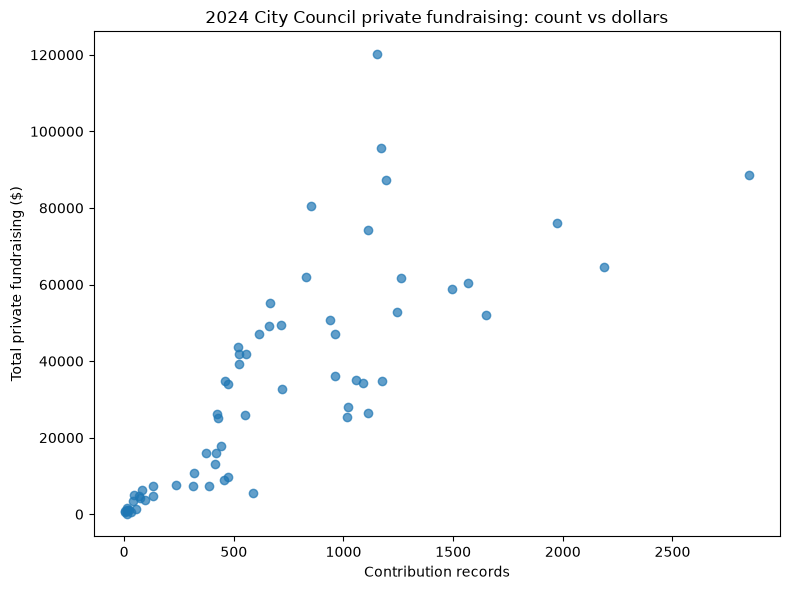

In [10]:
fig, ax = plt.subplots(
    figsize=(8, 6)
)

ax.scatter(
    candidate_summary["total_contribution_count"],
    candidate_summary["total_amount"],
    alpha=0.7,
)

ax.set_xlabel("Contribution records")
ax.set_ylabel("Total private fundraising ($)")
ax.set_title(
    "2024 City Council private fundraising: count vs dollars"
)

plt.tight_layout()
plt.show()


## 11. Export

Source prefixes make the 2024 OpenElections/Portland-contributions profiles
distinguishable from the 2024 ORESTAR fundraising profiles.


In [11]:
summary_path = (
    OUTPUT_DIR
    / "openelections_candidate_fundraising_summary.csv"
)

long_path = (
    OUTPUT_DIR
    / "openelections_candidate_fundraising_profiles_long.csv"
)

wide_path = (
    OUTPUT_DIR
    / "openelections_candidate_fundraising_profiles_wide.csv"
)

candidate_summary.to_csv(
    summary_path,
    index=False,
)

profile_long.to_csv(
    long_path,
    index=False,
)

profile_wide.to_csv(
    wide_path,
    index=False,
)

print("SAVED", summary_path)
print("SAVED", long_path)
print("SAVED", wide_path)


SAVED /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis/data/processed/fundraising/2024/city_council/openelections_candidate_fundraising_summary.csv
SAVED /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis/data/processed/fundraising/2024/city_council/openelections_candidate_fundraising_profiles_long.csv
SAVED /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis/data/processed/fundraising/2024/city_council/openelections_candidate_fundraising_profiles_wide.csv
